In [3]:
import json
import os
from pathlib import Path
from collections import Counter

import pandas as pd
from PIL import Image, ImageDraw

print("Dossier de travail actuel (cwd) :", Path.cwd())


def find_split_dir(candidates_roots, split_names):
    """
    Cherche un dossier de split (train ou test) parmi plusieurs noms possibles
    (ex: "training_data" ou "raw"), sous plusieurs racines possibles.
    Retourne le premier dossier trouvé contenant à la fois images/ et annotations/.
    """
    for root in candidates_roots:
        for name in split_names:
            candidate = root / name
            if (candidate / "images").is_dir() and (candidate / "annotations").is_dir():
                return candidate
    return None


HERE = Path.cwd()
POSSIBLE_ROOTS = [HERE, HERE.parent, HERE / "dataset", HERE.parent / "dataset",
                  HERE / "data", HERE.parent / "data"]
# on ne garde que les racines qui existent réellement
POSSIBLE_ROOTS = [r for r in POSSIBLE_ROOTS if r.exists()]

RAW_DIR = find_split_dir(POSSIBLE_ROOTS, ["training_data", "raw"])
TEST_DIR = find_split_dir(POSSIBLE_ROOTS, ["testing_data", "raw_test"])

if RAW_DIR is None:
    raise FileNotFoundError(
        "Impossible de trouver le dossier d'entraînement du dataset FUNSD. "
        f"Racines explorées : {POSSIBLE_ROOTS}. "
        "Vérifie que le dossier 'dataset' (avec training_data/testing_data) "
        "se trouve bien à côté de ce notebook, ou un dossier au-dessus."
    )

print("Dossier train détecté :", RAW_DIR.resolve())
print("Dossier test détecté  :", TEST_DIR.resolve() if TEST_DIR else "non trouvé (optionnel)")



Dossier de travail actuel (cwd) : c:\Users\alkam\Desktop\PFA
Dossier train détecté : C:\Users\alkam\Desktop\PFA\dataset\training_data
Dossier test détecté  : C:\Users\alkam\Desktop\PFA\dataset\testing_data


In [4]:
def build_manifest(split_dir):
    images = sorted((split_dir / "images").glob("*.png"))
    manifest = []
    for img in images:
        ann = split_dir / "annotations" / f"{img.stem}.json"
        if ann.exists():
            manifest.append({"image": img.name, "annotation": ann.name})
    return manifest


manifest = build_manifest(RAW_DIR)
manifest_test = build_manifest(TEST_DIR) if TEST_DIR else []

print(f"Documents (train) : {len(manifest)}")
print(f"Documents (test)  : {len(manifest_test)}")
manifest[:3]


Documents (train) : 149
Documents (test)  : 50


[{'image': '0000971160.png', 'annotation': '0000971160.json'},
 {'image': '0000989556.png', 'annotation': '0000989556.json'},
 {'image': '0000990274.png', 'annotation': '0000990274.json'}]

In [ ]:
label_counter = Counter()
n_words_total = 0
n_linkings_total = 0
n_entities_per_doc = []

for entry in manifest:
    ann_i = json.loads((RAW_DIR / "annotations" / entry["annotation"]).read_text(encoding="utf-8"))
    n_entities_per_doc.append(len(ann_i["form"]))
    for item in ann_i["form"]:
        label_counter[item["label"]] += 1
        n_words_total += len(item["words"])
        n_linkings_total += len(item.get("linking", []))

stats_df = pd.DataFrame(label_counter.items(), columns=["label", "count"]).sort_values("count", ascending=False)
print(f"Documents : {len(manifest)}")
print(f"Entités totales : {sum(label_counter.values())}")
print(f"Entités / document (moyenne) : {sum(n_entities_per_doc)/len(n_entities_per_doc):.1f}")
print(f"Mots totaux : {n_words_total}")
print(f"Relations question-réponse (linking) : {n_linkings_total}")
stats_df


Documents : 149
Entités totales : 7411
Entités / document (moyenne) : 49.7
Mots totaux : 22512
Relations question-réponse (linking) : 8472


,label,count
1,question,3266
2,answer,2802
0,other,902
3,header,441


In [5]:
sample_entry = manifest[0]
ann = json.loads((RAW_DIR / "annotations" / sample_entry["annotation"]).read_text(encoding="utf-8"))

print(f"Document exemple : {sample_entry['image']}")
print(json.dumps(ann["form"][:3], ensure_ascii=False, indent=2))


Document exemple : 0000971160.png
[
  {
    "box": [
      292,
      91,
      376,
      175
    ],
    "text": "R&D",
    "label": "other",
    "words": [
      {
        "box": [
          292,
          91,
          376,
          175
        ],
        "text": "R&D"
      }
    ],
    "linking": [],
    "id": 0
  },
  {
    "box": [
      219,
      316,
      225,
      327
    ],
    "text": ":",
    "label": "question",
    "words": [
      {
        "box": [
          219,
          316,
          225,
          327
        ],
        "text": ":"
      }
    ],
    "linking": [],
    "id": 1
  },
  {
    "box": [
      95,
      355,
      169,
      370
    ],
    "text": "Suggestion:",
    "label": "question",
    "words": [
      {
        "box": [
          95,
          355,
          169,
          370
        ],
        "text": "Suggestion:"
      }
    ],
    "linking": [
      [
        2,
        16
      ]
    ],
    "id": 2
  }
]


In [6]:
label_counter = Counter()
n_words_total = 0
n_linkings_total = 0
n_entities_per_doc = []

for entry in manifest:
    ann_i = json.loads((RAW_DIR / "annotations" / entry["annotation"]).read_text(encoding="utf-8"))
    n_entities_per_doc.append(len(ann_i["form"]))
    for item in ann_i["form"]:
        label_counter[item["label"]] += 1
        n_words_total += len(item["words"])
        n_linkings_total += len(item.get("linking", []))

stats_df = pd.DataFrame(label_counter.items(), columns=["label", "count"]).sort_values("count", ascending=False)
print(f"Documents : {len(manifest)}")
print(f"Entités totales : {sum(label_counter.values())}")
print(f"Entités / document (moyenne) : {sum(n_entities_per_doc)/len(n_entities_per_doc):.1f}")
print(f"Mots totaux : {n_words_total}")
print(f"Relations question-réponse (linking) : {n_linkings_total}")
stats_df


Documents : 149
Entités totales : 7411
Entités / document (moyenne) : 49.7
Mots totaux : 22512
Relations question-réponse (linking) : 8472


,label,count
1,question,3266
2,answer,2802
0,other,902
3,header,441


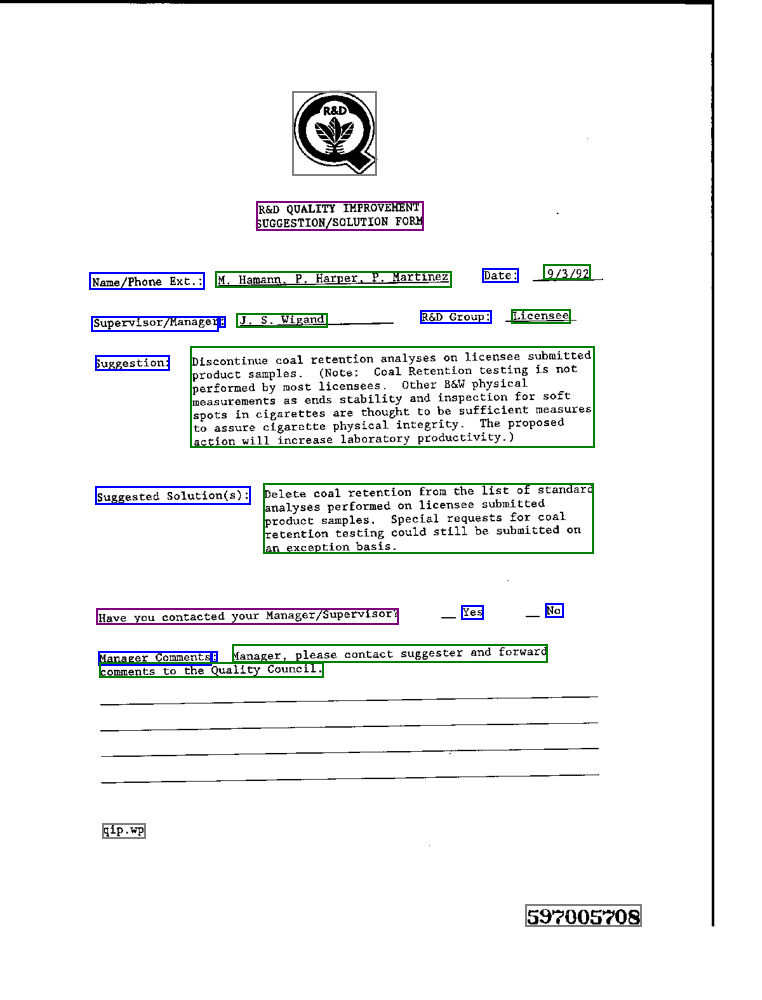

In [7]:
COLORS = {"header": "purple", "question": "blue", "answer": "green", "other": "gray"}

img_path = RAW_DIR / "images" / sample_entry["image"]
img = Image.open(img_path).convert("RGB")
draw_img = img.copy()
draw = ImageDraw.Draw(draw_img)

for item in ann["form"]:
    x0, y0, x1, y1 = item["box"]
    color = COLORS.get(item["label"], "black")
    draw.rectangle([x0, y0, x1, y1], outline=color, width=2)

out_dir = Path("results") / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
draw_img.save(out_dir / "phase1_annotated_sample.png")
draw_img


In [8]:
question_texts = Counter()
for entry in manifest:
    ann_i = json.loads((RAW_DIR / "annotations" / entry["annotation"]).read_text(encoding="utf-8"))
    for item in ann_i["form"]:
        if item["label"] == "question" and item["text"].strip():
            question_texts[item["text"].strip().upper()] += 1

pd.DataFrame(question_texts.most_common(20), columns=["libellé_question", "occurrences"])


,libellé_question,occurrences
0,DATE,87
1,DATE:,61
2,APPROVED BY:,28
3,CC:,27
4,TO:,27
5,FROM:,26
6,NO,18
7,YES,17
8,COMMENTS:,13
9,DESCRIPTION:,12


## 5. Note de synthèse (résultats attendus de la Phase 1)

- **Dataset** : FUNSD officiel — 149 documents d'entraînement / 50 documents de test,
  memos administratifs américains scannés.
- **Structure comprise** : chaque document = 1 image + 1 JSON avec entités `header /
  question / answer / other`, bounding boxes, et relations `linking` question→réponse.
- **Volume mesuré** : ~3266 entités `question`, ~2802 `answer`, ~902 `other`, ~441
  `header` sur l'ensemble du train set (valeurs exactes affichées ci-dessus).
- **Constat important** : les libellés de question dominants sont `DATE`, `TO:`,
  `FROM:`, `CC:`, `APPROVED BY:`, `SUBJECT:`, etc. — **pas** de champs `Nom / Montant /
  Adresse / Téléphone` au sens administratif marocain classique.
- **Conséquence méthodologique pour la Phase 5** : deux options possibles conformes au
  cahier des charges :
  1. Recentrer l'extraction d'entités sur les paires question-réponse *natives* de
     FUNSD (DATE, TO, FROM, SUBJECT...) plutôt que sur les 6 champs métier initiaux.
  2. Conserver les 6 champs métier comme objectif final, mais les valider/compléter
     sur un petit jeu de documents synthétiques ou un dataset de reçus/factures en
     parallèle (le module `src/sample_data_generator.py` déjà écrit peut servir à
     cela si besoin).
- **Environnement prêt** : Python 3, OpenCV, Tesseract OCR, pandas, PIL, tous
  fonctionnels dans l'environnement de travail.
